# Indução de Regras de Classificação

**Projeto:** DSS para Previsão de Reincidência Criminal  
**Dados:** NIJ Recidivism Forecasting Challenge (Georgia, EUA)  

> **Convenção de classe adotada (sugestão do professor):**  
> A classe alvo é **Não Reincidiu (1)** — a classe minoritária (42,3%).  
> Reincidiu = 0, Não Reincidiu = 1.  
> Isso torna as métricas mais expressivas: Lift > 1 identifica perfis com
> **menor risco de reincidência** do que a média da população.

Este notebook implementa a extração e análise de **regras de classificação** usando duas abordagens:

1. **Regras da Árvore de Decisão** — cada caminho raiz→folha como regra explícita
2. **Algoritmo Apriori** — indução direta de regras a partir dos dados

Métricas avaliadas (conforme slides do professor):
- **Cobertura** = N_C / N — representatividade da regra na amostra
- **Confiança** = N_AC / N_C — % da classe alvo (Não Reincidiu) na regra
- **Lift** = Confiança_regra / Confiança_amostra — ganho sobre o acaso
- **p-value** — significância estatística via teste binomial unilateral

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.cm as cm
from scipy.stats import binomtest
from sklearn.tree import DecisionTreeClassifier, _tree
from sklearn.model_selection import train_test_split
from mlxtend.frequent_patterns import apriori, association_rules

# !pip install mlxtend   # descomente se necessário

# Dados já preparados e codificados (exportados do notebook principal)
ARQUIVO = 'dados/dados_transformados.csv'   # ajuste o caminho se necessário
LABEL   = 'Recidivism_Within_3years'
# Convenção: 0 = Reincidiu | 1 = Não Reincidiu  (classe alvo = 1)
CLASSE_ALVO_NOME = 'Não Reincidiu'
SEED    = 42

plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 12,
                     'axes.labelsize': 10, 'figure.figsize': (10, 5)})


In [6]:
df = pd.read_csv(ARQUIVO)

print(f'Dataset: {df.shape[0]:,} registros x {df.shape[1]} colunas')
print(f'Valores ausentes: {df.isnull().sum().sum()}')
print(f'\nDistribuição da variável resposta:')
vc = df[LABEL].value_counts().sort_index()
print(f'  0 — Reincidiu        : {vc[0]:>6,} ({vc[0]/len(df)*100:.1f}%)')
print(f'  1 — Não Reincidiu    : {vc[1]:>6,} ({vc[1]/len(df)*100:.1f}%)')
print(f'\n→ Classe alvo (1 = Não Reincidiu): {vc[1]/len(df)*100:.1f}% — classe MINORITÁRIA')


Dataset: 25,835 registros x 44 colunas
Valores ausentes: 0

Distribuição da variável resposta:
  0 — Reincidiu        : 14,904 (57.7%)
  1 — Não Reincidiu    : 10,931 (42.3%)

→ Classe alvo (1 = Não Reincidiu): 42.3% — classe MINORITÁRIA


In [7]:
# =============================================================================
# DIVISÃO TREINO / TESTE E SELEÇÃO DE VARIÁVEIS
# Variáveis selecionadas pela importância Gini da árvore completa
# =============================================================================

FEATURES = [c for c in df.columns if c != LABEL]
X, y     = df[FEATURES], df[LABEL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)
print(f'Treino: {len(X_train):,} | Teste: {len(X_test):,}')
print(f'Taxa de Não Reincidência (classe alvo) — '
      f'treino: {y_train.mean()*100:.1f}%  |  teste: {y_test.mean()*100:.1f}%')

# Treinar árvore completa apenas para extrair importância das variáveis
dt_completa = DecisionTreeClassifier(criterion='gini', random_state=SEED)
dt_completa.fit(X_train, y_train)

imp = pd.Series(dt_completa.feature_importances_, index=FEATURES)
top20 = imp[imp > 0].sort_values(ascending=False).head(20)
VARS_SELECIONADAS = top20[top20 >= top20.mean()].index.tolist()

X_train_sel = X_train[VARS_SELECIONADAS]
X_test_sel  = X_test[VARS_SELECIONADAS]

print(f'\nVariáveis selecionadas ({len(VARS_SELECIONADAS)}):')
for v in VARS_SELECIONADAS:
    print(f'  {v:<45}  importância={top20[v]:.4f}')


Treino: 18,084 | Teste: 7,751
Taxa de Não Reincidência (classe alvo) — treino: 42.3%  |  teste: 42.3%

Variáveis selecionadas (5):
  Jobs_Per_Year                                  importância=0.1270
  Avg_Days_per_DrugTest                          importância=0.1005
  Prior_Arrest_Episodes_Felony                   importância=0.0620
  Age_at_Release                                 importância=0.0525
  Supervision_Risk_Score_First                   importância=0.0463


## 1. Regras da Árvore de Decisão

Cada caminho da raiz até uma folha define uma regra no formato  
`SE <condições> ENTÃO <predição>`  

Com a nova convenção de classe, as regras com **Lift > 1** identificam perfis com **maior probabilidade de NÃO reincidir** do que a média da população — ou seja, perfis de baixo risco. Regras com Lift < 1 identificam perfis de alto risco.

A árvore **particiona** o espaço de atributos: cada registro cai em exatamente uma folha, sem sobreposição, garantindo consistência total.

In [8]:
# =============================================================================
# FUNÇÕES PARA EXTRAÇÃO E EXIBIÇÃO DE REGRAS
# =============================================================================

def extrair_regras_arvore(modelo, feature_names, X_tr, y_tr, X_te=None, y_te=None):
    """
    Extrai todos os caminhos raiz → folha da árvore como regras de classificação.

    Métricas calculadas (conforme nomenclatura do professor):
      - Cobertura  : N_C / N  (% da amostra coberta pela regra)
      - Confiança  : N_AC / N_C  (% da classe-alvo dentro da regra)
      - Lift       : Confiança_regra / Confiança_amostra
      - p-value    : teste binomial unilateral (H1: confiança > confiança_amostra)
    """
    tree = modelo.tree_
    feature_names = list(feature_names)
    N   = len(y_tr)
    N_a = int(y_tr.sum())
    p0  = N_a / N    # confiança da amostra (probabilidade a priori)
    regras = []

    def percorrer(node_id, condicoes):
        eh_folha = tree.children_left[node_id] == _tree.TREE_LEAF
        if eh_folha:
            mask_tr = modelo.apply(X_tr) == node_id
            N_C  = int(mask_tr.sum())
            N_AC = int(y_tr[mask_tr].sum())
            if N_C == 0:
                return
            cobertura = N_C / N
            confianca = N_AC / N_C
            lift      = confianca / p0
            pvalue    = binomtest(N_AC, N_C, p0, alternative='greater').pvalue
            pred = 'Não Reincidiu' if N_AC > (N_C - N_AC) else 'Reincidiu'

            entrada = {
                'condicoes'    : list(condicoes),
                'predicao'     : pred,
                'N_C'          : N_C,
                'N_AC'         : N_AC,
                'cobertura_pct': round(cobertura * 100, 1),
                'confianca_pct': round(confianca * 100, 1),
                'lift'         : round(lift, 3),
                'pvalue'       : pvalue,
                'significativa': pvalue < 0.05,
            }
            if X_te is not None and y_te is not None:
                mask_te = modelo.apply(X_te) == node_id
                N_C_te  = int(mask_te.sum())
                N_AC_te = int(y_te[mask_te].sum())
                conf_te = N_AC_te / N_C_te if N_C_te > 0 else 0
                entrada.update({
                    'N_C_teste'        : N_C_te,
                    'confianca_teste'  : round(conf_te * 100, 1),
                    'lift_teste'       : round(conf_te / p0, 3),
                })
            regras.append(entrada)
        else:
            feat  = feature_names[tree.feature[node_id]]
            thres = round(float(tree.threshold[node_id]), 4)
            percorrer(tree.children_left[node_id],  condicoes + [(feat, '<=', thres)])
            percorrer(tree.children_right[node_id], condicoes + [(feat, '>',  thres)])

    percorrer(0, [])
    return sorted(regras, key=lambda r: r['lift'], reverse=True)


def formatar_regra(r, idx, p0):
    """Formata uma regra para exibição no padrão do professor."""
    linhas = [
        f"{'='*65}",
        f"Regra {idx:>2}  |  Predição: {r['predicao']}",
        f"{'─'*65}",
    ]
    for feat, op, val in r['condicoes']:
        linhas.append(f"  SE  {feat} {op} {val}")
    linhas += [
        f"{'─'*65}",
        f"  Cobertura   (N_C/N)       : {r['cobertura_pct']:>5.1f}%  ({r['N_C']:,} registros)",
        f"  Confiança   (N_AC/N_C)    : {r['confianca_pct']:>5.1f}%  "
        f"(amostra: {p0*100:.1f}%)",
        f"  Lift                      : {r['lift']:>5.3f}  "
        f"({'↑ menos risco' if r['lift']>1 else '↓ mais risco'})"
        f"  Significância (p-value)   : {r['pvalue']:.2e}  "
        f"{'✓' if r['significativa'] else '✗'}",
    ]
    if 'confianca_teste' in r:
        linhas.append(
            f"  Confiança no teste        : {r['confianca_teste']:>5.1f}%  "
            f"(Lift teste: {r['lift_teste']:.3f})"
        )
    return '\n'.join(linhas)


In [9]:
# =============================================================================
# REGRAS DA ÁRVORE PODADA (max_depth = 3)
# Classe alvo: 1 = Não Reincidiu (42,3% da amostra)
# Lift > 1 → grupo com MENOR risco de reincidência que a média
# =============================================================================

p0 = y_train.mean()    # confiança da amostra = taxa de NÃO reincidência
print(f'Confiança da amostra (taxa de Não Reincidência): {p0*100:.1f}%')
print(f'  → Lift > 1 identifica perfis de BAIXO RISCO de reincidência\n')

dt_podada = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=SEED)
dt_podada.fit(X_train_sel, y_train)

regras_arvore = extrair_regras_arvore(
    dt_podada, VARS_SELECIONADAS,
    X_train_sel, y_train,
    X_test_sel,  y_test,
)

print(f'Total de regras : {len(regras_arvore)}')
print(f'Significativas  : {sum(1 for r in regras_arvore if r["significativa"])} '
      f'(p < 0.05)\n')

for i, r in enumerate(regras_arvore, 1):
    print(formatar_regra(r, i, p0))
    print()


Confiança da amostra (taxa de Não Reincidência): 42.3%
  → Lift > 1 identifica perfis de BAIXO RISCO de reincidência

Total de regras : 8
Significativas  : 4 (p < 0.05)

Regra  1  |  Predição: Não Reincidiu
─────────────────────────────────────────────────────────────────
  SE  Prior_Arrest_Episodes_Felony <= 2.5
  SE  Age_at_Release > 1.5
  SE  Age_at_Release > 3.5
─────────────────────────────────────────────────────────────────
  Cobertura   (N_C/N)       :   5.1%  (915 registros)
  Confiança   (N_AC/N_C)    :  79.8%  (amostra: 42.3%)
  Lift                      : 1.886  (↑ menos risco)  Significância (p-value)   : 5.60e-119  ✓
  Confiança no teste        :  78.4%  (Lift teste: 1.854)

Regra  2  |  Predição: Não Reincidiu
─────────────────────────────────────────────────────────────────
  SE  Prior_Arrest_Episodes_Felony <= 2.5
  SE  Age_at_Release > 1.5
  SE  Age_at_Release <= 3.5
─────────────────────────────────────────────────────────────────
  Cobertura   (N_C/N)       :   5.5%

In [10]:
# Tabela resumo das regras ordenadas por Lift
rows = []
for i, r in enumerate(regras_arvore, 1):
    conds = ' E '.join([f"{f} {op} {v}" for f, op, v in r['condicoes']])
    rows.append({
        'Regra'          : i,
        'Predição'       : r['predicao'],
        'Condições'      : conds,
        'Cobertura (%)'  : r['cobertura_pct'],
        'Confiança (%)'  : r['confianca_pct'],
        'Lift'           : r['lift'],
        'Lift (teste)'   : r.get('lift_teste', '-'),
        'p-value'        : f"{r['pvalue']:.2e}",
        'Sig.'           : '✓' if r['significativa'] else '✗',
    })

df_regras = pd.DataFrame(rows).set_index('Regra')
pd.set_option('display.max_colwidth', 90)
display(df_regras)


,Predição,Condições,Cobertura (%),Confiança (%),Lift,Lift (teste),p-value,Sig.
Regra,,,,,,,,
1,Não Reincidiu,Prior_Arrest_Episodes_Felony <= 2.5 E Age_at_Release > 1.5 E Age_at_Release > 3.5,5.1,79.8,1.886,1.854,5.60e-119,✓
2,Não Reincidiu,Prior_Arrest_Episodes_Felony <= 2.5 E Age_at_Release > 1.5 E Age_at_Release <= 3.5,5.5,64.7,1.529,1.501,2.73e-46,✓
3,Não Reincidiu,Prior_Arrest_Episodes_Felony > 2.5 E Age_at_Release > 2.5 E Prior_Arrest_Episodes_Felo...,19.4,56.7,1.340,1.343,5.62e-66,✓
4,Não Reincidiu,Prior_Arrest_Episodes_Felony <= 2.5 E Age_at_Release <= 1.5 E Jobs_Per_Year > 0.0749,6.3,50.6,1.196,1.251,9.51e-09,✓
5,Reincidiu,Prior_Arrest_Episodes_Felony > 2.5 E Age_at_Release > 2.5 E Prior_Arrest_Episodes_Felo...,26.0,36.2,0.855,0.826,1.00e+00,✗
6,Reincidiu,Prior_Arrest_Episodes_Felony > 2.5 E Age_at_Release <= 2.5 E Jobs_Per_Year > 0.1457,23.2,34.2,0.809,0.813,1.00e+00,✗
7,Reincidiu,Prior_Arrest_Episodes_Felony <= 2.5 E Age_at_Release <= 1.5 E Jobs_Per_Year <= 0.0749,2.5,30.7,0.725,0.735,1.00e+00,✗
8,Reincidiu,Prior_Arrest_Episodes_Felony > 2.5 E Age_at_Release <= 2.5 E Jobs_Per_Year <= 0.1457,11.9,19.7,0.466,0.476,1.00e+00,✗


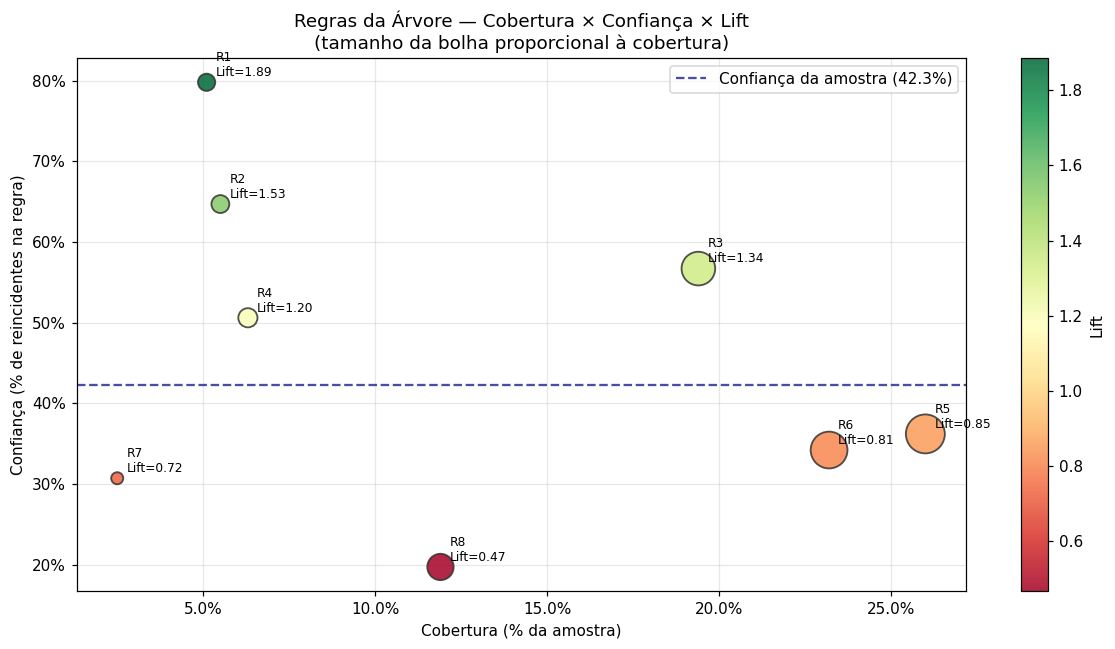

In [11]:
# Gráfico: Cobertura × Confiança × Lift (bolhas)
# Tamanho = cobertura | Cor = lift | Linha = confiança da amostra
fig, ax = plt.subplots(figsize=(11, 6))

coberturas = [r['cobertura_pct']  for r in regras_arvore]
confianças = [r['confianca_pct']  for r in regras_arvore]
lifts      = [r['lift']           for r in regras_arvore]

norm    = plt.Normalize(min(lifts), max(lifts))
scatter = ax.scatter(
    coberturas, confianças,
    s=[c * 25 for c in coberturas],
    c=lifts, cmap='RdYlGn', norm=norm,
    alpha=0.85, edgecolors='#333', linewidths=1.2, zorder=3
)

ax.axhline(p0 * 100, color='navy', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'Confiança da amostra ({p0*100:.1f}%)')

for i, (cob, conf, lift) in enumerate(zip(coberturas, confianças, lifts), 1):
    ax.annotate(f'R{i}\nLift={lift:.2f}', (cob, conf),
                textcoords='offset points', xytext=(6, 4), fontsize=8)

plt.colorbar(scatter, ax=ax, label='Lift')
ax.set_xlabel('Cobertura (% da amostra)')
ax.set_ylabel('Confiança (% de reincidentes na regra)')
ax.set_title('Regras da Árvore — Cobertura × Confiança × Lift\n'
             '(tamanho da bolha proporcional à cobertura)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


### 1.1 Efeito da profundidade no conjunto de regras

Quanto maior a profundidade, mais regras são geradas — cada uma mais específica (menor cobertura) e mais confiante. A profundidade controla diretamente o trade-off entre **generalidade** e **especificidade** das regras.

In [12]:
# =============================================================================
# EFEITO DA PROFUNDIDADE NO CONJUNTO DE REGRAS
# Mais profundidade = mais regras, maior confiança, menor cobertura
# =============================================================================

print(f"{'Depth':>6} {'Regras':>7} {'Sig.':>5} {'Cob.Média':>10} "
      f"{'Conf.Média':>11} {'Lift Máx':>9} {'Lift Mín':>9}")
print('─' * 65)

for depth in [2, 3, 4, 5, 6]:
    dt_d = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=SEED)
    dt_d.fit(X_train_sel, y_train)
    regs = extrair_regras_arvore(dt_d, VARS_SELECIONADAS,
                                  X_train_sel, y_train,
                                  X_test_sel, y_test)
    n_sig = sum(1 for r in regs if r['significativa'])
    print(f"{depth:>6} {len(regs):>7} {n_sig:>5} "
          f"{np.mean([r['cobertura_pct'] for r in regs]):>9.1f}% "
          f"{np.mean([r['confianca_pct'] for r in regs]):>10.1f}% "
          f"{max(r['lift'] for r in regs):>9.3f} "
          f"{min(r['lift'] for r in regs):>9.3f}")


 Depth  Regras  Sig.  Cob.Média  Conf.Média  Lift Máx  Lift Mín
─────────────────────────────────────────────────────────────────
     2       4     3      25.0%       47.8%     1.699     0.693
     3       8     4      12.5%       46.6%     1.886     0.466
     4      16    10       6.3%       46.0%     1.922     0.345
     5      32    13       3.1%       47.8%     2.364     0.000
     6      62    23       1.6%       44.8%     2.364     0.000


## Indução de Regras com o Algoritmo Apriori

A abordagem anterior extrai regras **da estrutura da árvore** — hierárquicas, sem sobreposição, cobrindo 100% da amostra. O **Apriori** funciona de forma diferente: busca diretamente combinações de condições frequentes nos dados, sem impor estrutura hierárquica.

| Aspecto | Árvore de Decisão | Apriori |
|---|---|---|
| **Estrutura** | Hierárquica (cada nível depende do anterior) | Plana (regras independentes) |
| **Cobertura** | 100% da amostra (toda folha cobre algum grupo) | Parcial (pode não cobrir todos os registros) |
| **Sobreposição** | Nenhuma — partição exclusiva | Possível — um registro pode satisfazer várias regras |
| **Inconsistência** | Impossível por construção | Possível — requer tratamento explícito |

O Apriori exige dados **binários**: cada coluna representa uma característica e indica presença (1) ou ausência (0). Por isso binarizamos cada variável selecionada pela sua mediana antes de aplicar o algoritmo.

In [13]:
# =============================================================================
# BINARIZAÇÃO PARA O APRIORI
# Cada variável vira binária: acima da mediana (1) ou abaixo/igual (0)
# Classe alvo na coluna booleana: 'Nao_Reincidiu' (1 = Não Reincidiu)
# =============================================================================

df_ap = X_train_sel.copy()
colunas_bin = {}
for col in VARS_SELECIONADAS:
    mediana = df_ap[col].median()
    nome    = f'{col}_alto'
    df_ap[nome] = (df_ap[col] > mediana).astype(bool)
    colunas_bin[col] = (nome, mediana)

# Coluna alvo: True quando o indivíduo NÃO reincidiu (y == 1)
df_ap['Nao_Reincidiu'] = (y_train.values == 1)
df_bin = df_ap[[v for v, _ in colunas_bin.values()] + ['Nao_Reincidiu']].copy()

print('Binarização das variáveis (coluna_alto = acima da mediana):')
for col, (nome, med) in colunas_bin.items():
    pct_alto = df_bin[nome].mean() * 100
    print(f'  {nome:<50} mediana={med:.3f}  alto={pct_alto:.1f}%')
print(f'  {"Nao_Reincidiu":<50} (classe alvo: {df_bin["Nao_Reincidiu"].mean()*100:.1f}%)')

# =============================================================================
# APRIORI — itemsets frequentes e regras de classificação
# min_support   : cobertura mínima (5% da amostra)
# min_threshold : confiança mínima (40% — pois classe alvo é 42,3%,
#                 limiares altos descartariam regras relevantes)
# =============================================================================

print('\nBuscando itemsets frequentes...')
itemsets = apriori(df_bin, min_support=0.05, use_colnames=True, verbose=0)
print(f'Itemsets frequentes encontrados: {len(itemsets)}')

print('Gerando regras de associação...')
regras_ap_todas = association_rules(
    itemsets, metric='confidence', min_threshold=0.40,
    num_itemsets=len(itemsets)
)

# Filtrar apenas regras de CLASSIFICAÇÃO: consequente = 'Nao_Reincidiu'
regras_ap = regras_ap_todas[
    regras_ap_todas['consequents'].apply(lambda x: 'Nao_Reincidiu' in x)
].copy()

# Lift ajustado em relação à taxa base (confiança da amostra = taxa Não Reincidência)
regras_ap['lift_ajustado'] = regras_ap['confidence'] / p0
regras_ap = regras_ap.sort_values('lift_ajustado', ascending=False).reset_index(drop=True)

print(f'\nRegras de classificação (consequente=Nao_Reincidiu, conf≥40%): {len(regras_ap)}')
print(f'(Lift > 1 = perfil com MENOR risco de reincidência que a média)')


Binarização das variáveis (coluna_alto = acima da mediana):
  Jobs_Per_Year_alto                                 mediana=0.635  alto=48.7%
  Avg_Days_per_DrugTest_alto                         mediana=55.425  alto=38.3%
  Prior_Arrest_Episodes_Felony_alto                  mediana=5.000  alto=49.8%
  Age_at_Release_alto                                mediana=3.000  alto=36.1%
  Supervision_Risk_Score_First_alto                  mediana=6.000  alto=43.3%
  Nao_Reincidiu                                      (classe alvo: 42.3%)

Buscando itemsets frequentes...
Itemsets frequentes encontrados: 38
Gerando regras de associação...

Regras de classificação (consequente=Nao_Reincidiu, conf≥40%): 7
(Lift > 1 = perfil com MENOR risco de reincidência que a média)


In [14]:
# =============================================================================
# EXIBIÇÃO DAS REGRAS DO APRIORI com métricas do professor
# =============================================================================

print(f'Confiança da amostra (Não Reincidência): {p0*100:.1f}%')
print(f'Lift > 1 → perfil com MENOR risco de reincidência\n')

for i, row in regras_ap.head(10).iterrows():
    antec = sorted(list(row['antecedents']))
    conf  = row['confidence'] * 100
    sup   = row['support']   * 100
    lift  = row['lift_ajustado']
    N_C   = int(round(row['support'] * len(df_bin)))
    N_AC  = int(round(row['confidence'] * N_C))
    pv    = binomtest(N_AC, N_C, p0, alternative='greater').pvalue

    print(f'{'='*65}')
    print(f'Regra {i+1:>2}  |  Predição: Não Reincidiu  '
          f'({'↑ BAIXO RISCO' if lift > 1 else '↓ ALTO RISCO'})')
    print(f'{'─'*65}')
    for ant in antec:
        col_orig = ant.replace('_alto', '')
        med_val  = colunas_bin.get(col_orig, (None, '?'))[1]
        print(f'  SE  {ant}  (> {med_val:.3f})')
    print(f'{'─'*65}')
    print(f'  Cobertura   (N_C/N)     : {sup:>5.1f}%  ({N_C:,} registros)')
    print(f'  Confiança   (N_AC/N_C)  : {conf:>5.1f}%  '
          f'(amostra: {p0*100:.1f}%)')
    print(f'  Lift                    : {lift:>5.3f}  '
          f'({'↑ menos risco' if lift>1 else '↓ mais risco'})')
    print(f'  Significância (p-value) : {pv:.2e}  '
          f'{'✓ Significativa' if pv < 0.05 else '✗ Não significativa'}')
    print()

# Tabela resumo
rows_ap = []
for i, row in regras_ap.iterrows():
    N_C  = int(round(row['support'] * len(df_bin)))
    N_AC = int(round(row['confidence'] * N_C))
    pv   = binomtest(N_AC, N_C, p0, alternative='greater').pvalue
    rows_ap.append({
        'Regra'         : i + 1,
        'Antecedentes'  : ' E '.join(sorted(list(row['antecedents']))),
        'Cobertura (%)'  : round(row['support']      * 100, 1),
        'Confiança (%)'  : round(row['confidence']    * 100, 1),
        'Lift'           : round(row['lift_ajustado'], 3),
        'Risco'          : '↑ Baixo' if row['lift_ajustado'] > 1 else '↓ Alto',
        'p-value'        : f'{pv:.2e}',
        'Sig.'           : '✓' if pv < 0.05 else '✗',
    })

df_resumo_ap = pd.DataFrame(rows_ap).set_index('Regra')
display(df_resumo_ap)


Confiança da amostra (Não Reincidência): 42.3%
Lift > 1 → perfil com MENOR risco de reincidência

Regra  1  |  Predição: Não Reincidiu  (↑ BAIXO RISCO)
─────────────────────────────────────────────────────────────────
  SE  Age_at_Release_alto  (> 3.000)
  SE  Avg_Days_per_DrugTest_alto  (> 55.425)
─────────────────────────────────────────────────────────────────
  Cobertura   (N_C/N)     :   7.5%  (1,363 registros)
  Confiança   (N_AC/N_C)  :  52.9%  (amostra: 42.3%)
  Lift                    : 1.250  (↑ menos risco)
  Significância (p-value) : 2.43e-15  ✓ Significativa

Regra  2  |  Predição: Não Reincidiu  (↑ BAIXO RISCO)
─────────────────────────────────────────────────────────────────
  SE  Age_at_Release_alto  (> 3.000)
─────────────────────────────────────────────────────────────────
  Cobertura   (N_C/N)     :  18.9%  (3,412 registros)
  Confiança   (N_AC/N_C)  :  52.2%  (amostra: 42.3%)
  Lift                    : 1.235  (↑ menos risco)
  Significância (p-value) : 1.46e-31  ✓ 

,Antecedentes,Cobertura (%),Confiança (%),Lift,Risco,p-value,Sig.
Regra,,,,,,,
1,Age_at_Release_alto E Avg_Days_per_DrugTest_alto,7.5,52.9,1.250,↑ Baixo,2.43e-15,✓
2,Age_at_Release_alto,18.9,52.2,1.235,↑ Baixo,1.46e-31,✓
3,Age_at_Release_alto E Jobs_Per_Year_alto,7.9,48.6,1.148,↑ Baixo,1.06e-06,✓
4,Avg_Days_per_DrugTest_alto E Jobs_Per_Year_alto,7.6,43.6,1.030,↑ Baixo,1.72e-01,✗
5,Avg_Days_per_DrugTest_alto,16.5,43.1,1.019,↑ Baixo,1.87e-01,✗
6,Age_at_Release_alto E Prior_Arrest_Episodes_Felony_alto,10.1,42.3,1.000,↑ Baixo,5.09e-01,✗
7,Jobs_Per_Year_alto,20.3,41.7,0.985,↓ Alto,7.92e-01,✗


### 2.1 Consistência e cobertura do Apriori

Diferente da árvore, o Apriori pode gerar regras inconsistentes (mesmo perfil levando a predições opostas) e não cobre necessariamente 100% da amostra. Os registros não cobertos por nenhuma regra recebem a **regra default** — predizer a classe majoritária, que agora é **Reincidiu (0)**  
(57,7% da amostra) — ou seja, o default é de alto risco.

In [15]:
# =============================================================================
# VERIFICAÇÃO DE CONSISTÊNCIA E COBERTURA DO APRIORI
# =============================================================================

# Pares de regras com antecedentes sobrepostos mas consequentes distintos
# (inconsistência: o mesmo perfil leva a predições diferentes)
todas_regras_ap = association_rules(
    itemsets, metric='confidence', min_threshold=0.0,
    num_itemsets=len(itemsets)
)
n_conflitos = 0
for i in range(len(todas_regras_ap)):
    for j in range(i+1, len(todas_regras_ap)):
        r1, r2 = todas_regras_ap.iloc[i], todas_regras_ap.iloc[j]
        if (r1['antecedents'] & r2['antecedents']) and r1['consequents'] != r2['consequents']:
            n_conflitos += 1

print(f"Pares inconsistentes (antecedentes sobrepostos, consequentes distintos): {n_conflitos}")

# Cobertura total do conjunto de regras gerado
cobertos = set()
for _, row in regras_ap.iterrows():
    mask = pd.Series([True] * len(df_bin), index=df_bin.index)
    for ant in row['antecedents']:
        if ant in df_bin.columns:
            mask = mask & df_bin[ant]
    cobertos.update(df_bin[mask].index.tolist())

pct_cob = len(cobertos) / len(df_bin) * 100
print(f"\nCobertura total das {len(regras_ap)} regras do Apriori:")
print(f"  Registros cobertos       : {len(cobertos):,} ({pct_cob:.1f}%)")
print(f"  Sem cobertura (default)  : {len(df_bin)-len(cobertos):,} ({100-pct_cob:.1f}%)")
print(f"  Regra default            : Reincidiu — classe MAJORITÁRIA (57,7%)")
print(f"  (registros sem cobertura são tratados como ALTO RISCO por default)")

print(f"\n{'─'*50}")
print("Comparativo final:")
print(f"  Árvore (depth=3): {len(regras_arvore)} regras, cobertura=100%, "
      f"lift_máx={max(r['lift'] for r in regras_arvore):.3f}")
print(f"  Apriori         : {len(regras_ap)} regras, cobertura={pct_cob:.1f}%, "
      f"lift_máx={regras_ap['lift_ajustado'].max():.3f}")
print(f"\nNota: Lift > 1 = perfil de BAIXO risco | Lift < 1 = perfil de ALTO risco")


Pares inconsistentes (antecedentes sobrepostos, consequentes distintos): 2433

Cobertura total das 7 regras do Apriori:
  Registros cobertos       : 14,666 (81.1%)
  Sem cobertura (default)  : 3,418 (18.9%)
  Regra default            : Reincidiu — classe MAJORITÁRIA (57,7%)
  (registros sem cobertura são tratados como ALTO RISCO por default)

──────────────────────────────────────────────────
Comparativo final:
  Árvore (depth=3): 8 regras, cobertura=100%, lift_máx=1.886
  Apriori         : 7 regras, cobertura=81.1%, lift_máx=1.250

Nota: Lift > 1 = perfil de BAIXO risco | Lift < 1 = perfil de ALTO risco
